# 01 — Exploratory data analysis

Dengue × climate × elevation, on the unified district-month panel.

This notebook is a thin view over `dengue_climate.analysis.eda` and `dengue_climate.viz.plots`:
every number and figure is computed by those modules, so `analysis/eda.py` and this notebook can
never disagree. Running it top-to-bottom regenerates the figures in `outputs/figures/`.

In [9]:
import pandas as pd
from IPython.display import Image, display

from dengue_climate.config import get_path
from dengue_climate.analysis import eda
from dengue_climate.viz import plots

pd.set_option("display.precision", 2)
fig_dir = get_path("figures")


def show(path):
    """Display a saved figure inline."""
    display(Image(filename=str(path)))


panel = eda.load_panel()
print(
    f"{len(panel)} district-months | {panel['district'].nunique()} districts | "
    f"{panel['year'].min()}-{panel['year'].max()}"
)
panel.head(200)

2772 district-months | 77 districts | 2022-2024


,district,province,elevation_m,elevation_band,year,month,cases,precip,temp_mean,temp_max,temp_min,humidity
0,Achham,Sudurpaschim Province,2136.0,Mountain,2022,1,0,37.25,9.44,15.15,5.64,68.42
1,Achham,Sudurpaschim Province,2136.0,Mountain,2022,2,0,67.76,10.24,16.81,5.02,67.32
2,Achham,Sudurpaschim Province,2136.0,Mountain,2022,3,0,0.50,19.28,26.59,12.61,49.84
3,Achham,Sudurpaschim Province,2136.0,Mountain,2022,4,0,15.79,24.50,32.65,16.05,29.22
4,Achham,Sudurpaschim Province,2136.0,Mountain,2022,5,1,97.35,24.83,30.92,18.80,48.36
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Bajura,Sudurpaschim Province,2218.0,Hill,2023,4,0,32.72,11.24,17.08,5.65,57.76
196,Bajura,Sudurpaschim Province,2218.0,Hill,2023,5,0,49.45,13.70,19.30,8.57,61.19
197,Bajura,Sudurpaschim Province,2218.0,Hill,2023,6,2,89.36,17.63,23.23,12.61,67.96
198,Bajura,Sudurpaschim Province,2218.0,Hill,2023,7,2,166.60,17.63,21.46,14.46,86.88


## 1. Where cases concentrate

Total cases per elevation band, and the heaviest districts.

,total_cases,share_pct
elevation_band,,
Terai,40848,29.1
Hill,93000,66.2
Mountain,6564,4.7


,total_cases
district,
Kathmandu,22371
Sunsari,16891
Lalitpur,11599
Kaski,11006
Tanahun,10103
Bhaktapur,8038
Makwanpur,6474
Dhading,5222
Chitwan,4877


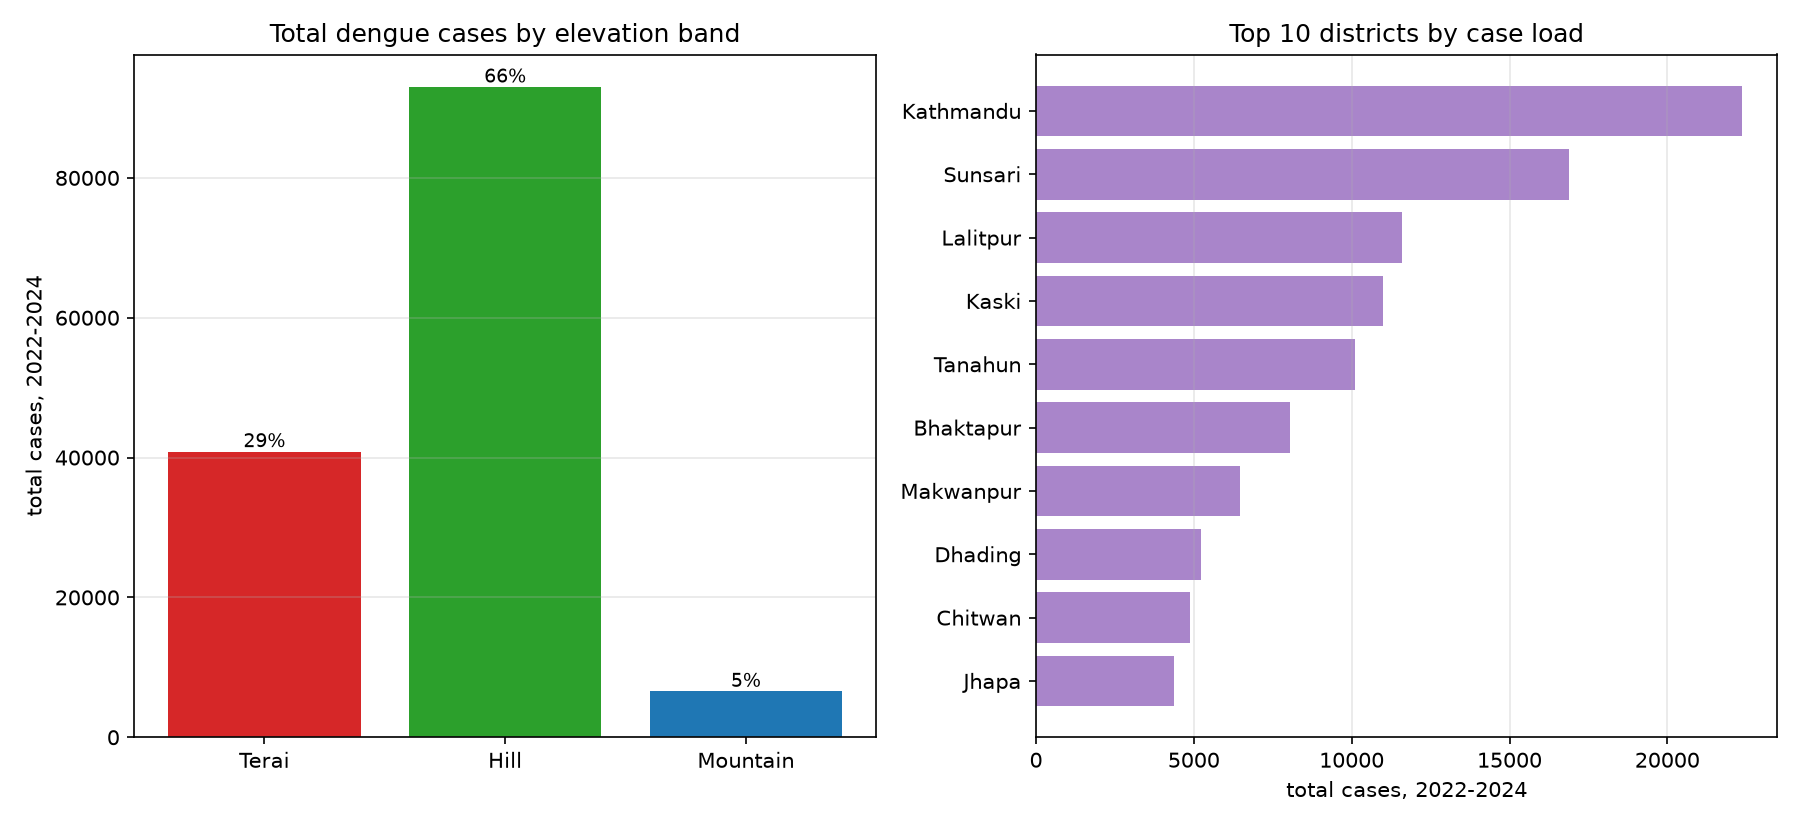

In [2]:
band_tbl, top = eda.concentration(panel)
display(band_tbl)
display(top.to_frame("total_cases"))
show(plots.plot_cases_concentration(panel, fig_dir / "cases_concentration.png"))

## 2. Seasonality

Cases per band over the three seasons against rainfall, then the averaged annual cycle.
Watch the peak month shift with elevation.

peak month of mean cases -> All: Sep; Terai: Sep; Hill: Sep; Mountain: Oct


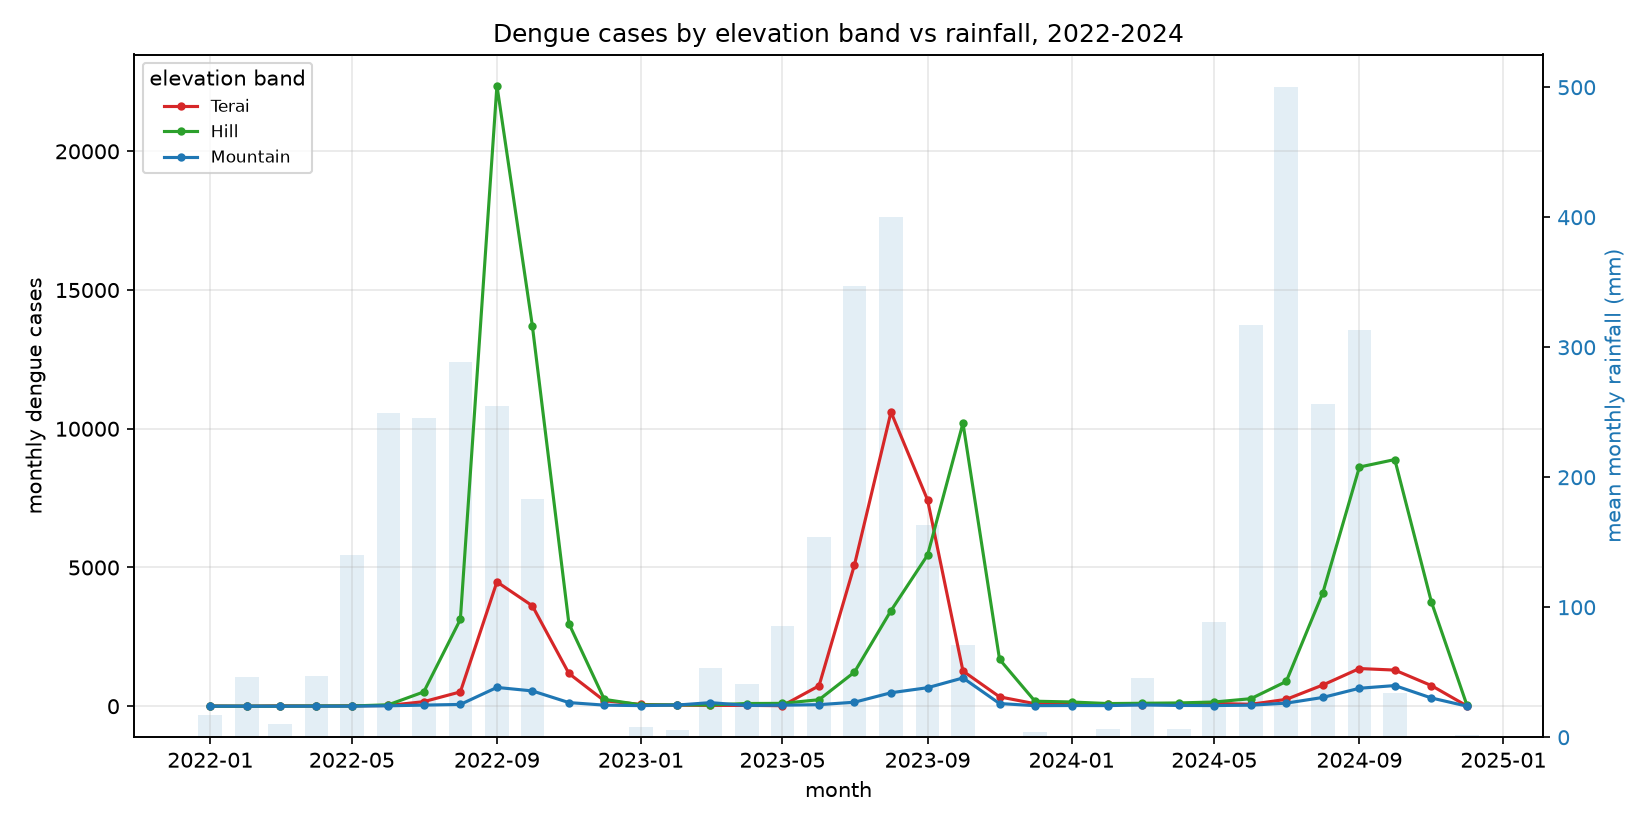

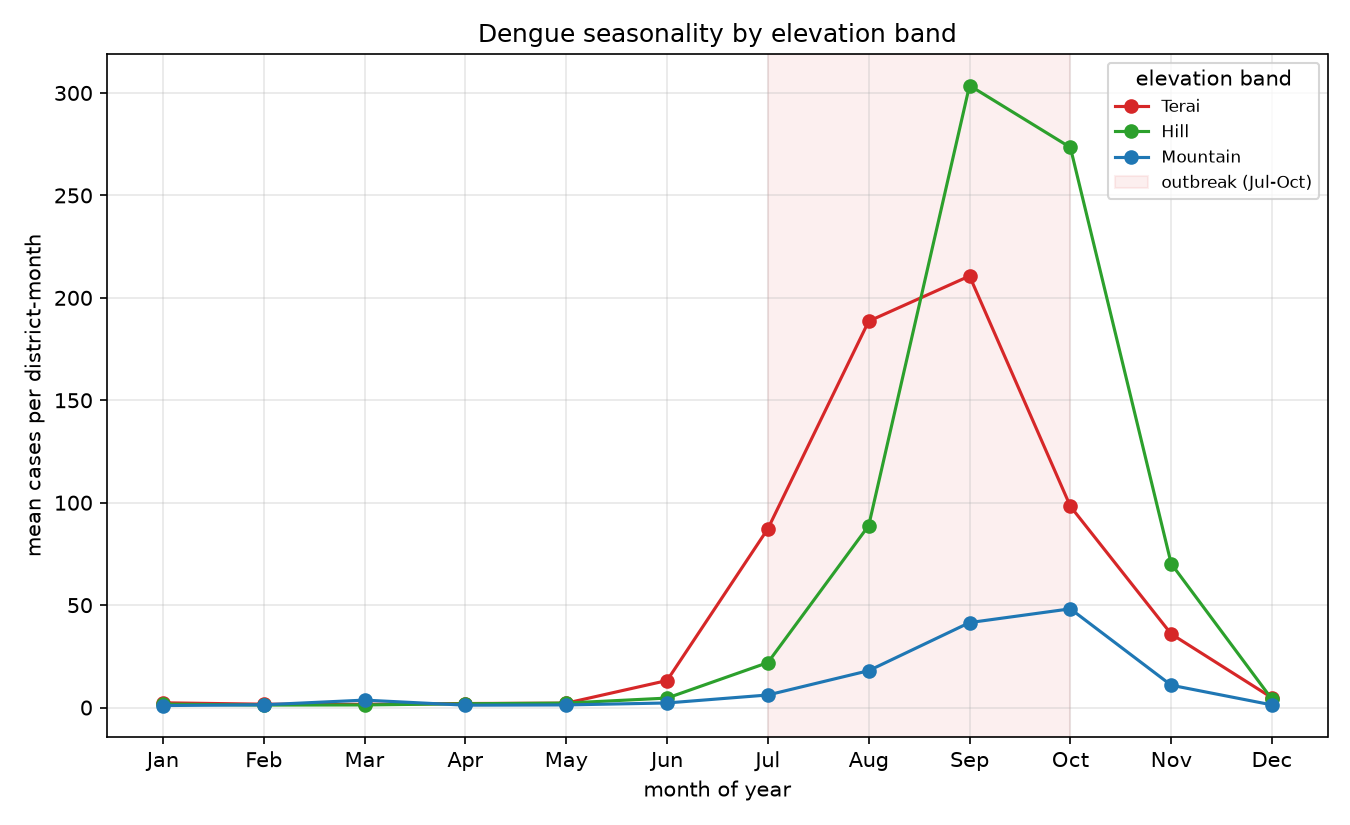

In [3]:
peaks = eda.peak_months(panel)
print("peak month of mean cases -> " + "; ".join(f"{b}: {m}" for b, m in peaks.items()))
show(plots.plot_cases_climate_overlay(panel, fig_dir / "cases_climate_overlay.png"))
show(plots.plot_seasonality_by_band(panel, fig_dir / "seasonality_by_band.png"))

## 3. Cases vs climate

Same-month Pearson correlation overall and split by band. Weak contemporaneous values are
expected — climate is thought to *lead* cases by 1-2 months.

,r_overall
precip,0.09
temp_mean,0.07
temp_max,0.04
temp_min,0.10
humidity,0.14


elevation_band,Terai,Hill,Mountain
cases,,,
precip,0.18,0.05,0.10
temp_mean,0.05,0.08,0.18
temp_max,-0.01,0.04,0.15
temp_min,0.09,0.11,0.20
humidity,0.16,0.16,0.22


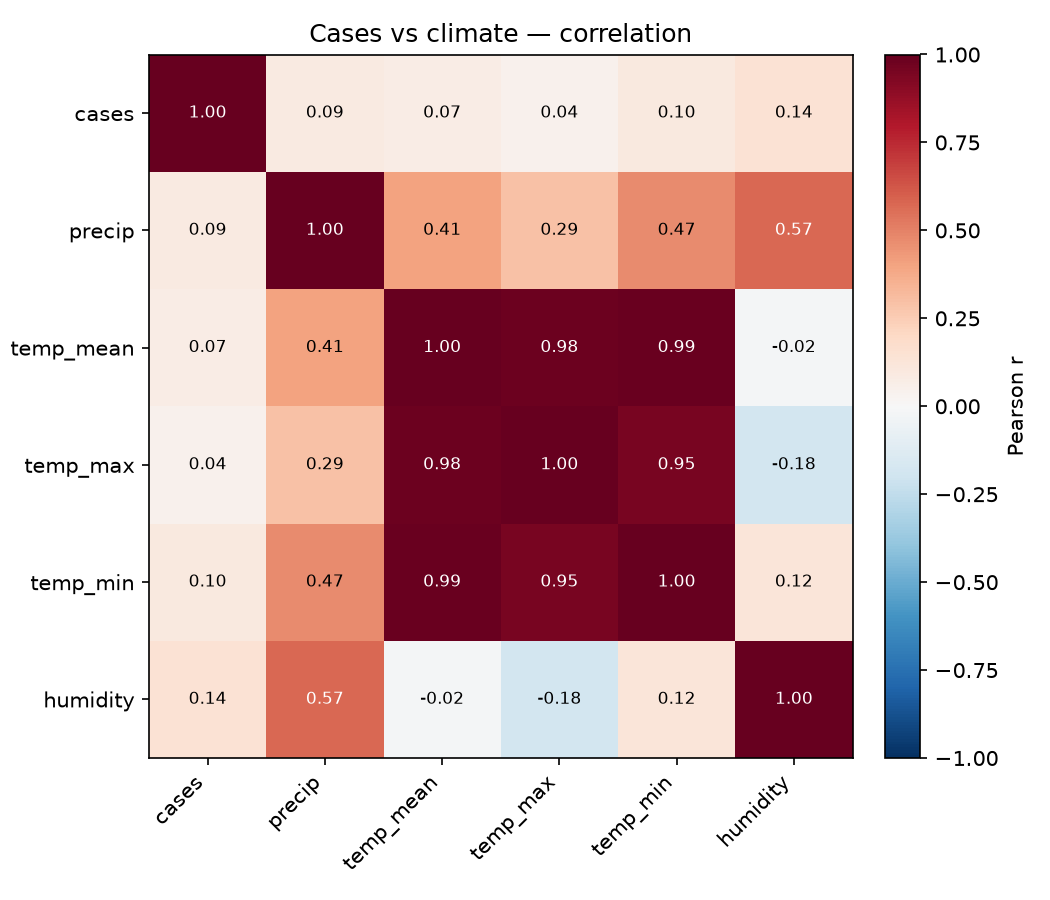

In [6]:
overall_corr, per_band_corr = eda.correlations(panel)
display(overall_corr.to_frame("r_overall"))
display(per_band_corr.T)
show(plots.plot_correlation_heatmap(panel, fig_dir / "correlation_heatmap.png"))

## 4. Distribution & overdispersion

If the variance dwarfs the mean, Poisson is too tight and a negative binomial is warranted.

,mean,variance,var_mean_ratio,pct_zero
All,50.7,125673.9,2481.0,36.7
Terai,54.0,134410.1,2487.6,27.4
Hill,64.6,169846.8,2629.9,35.7
Mountain,11.4,2047.9,179.7,51.4


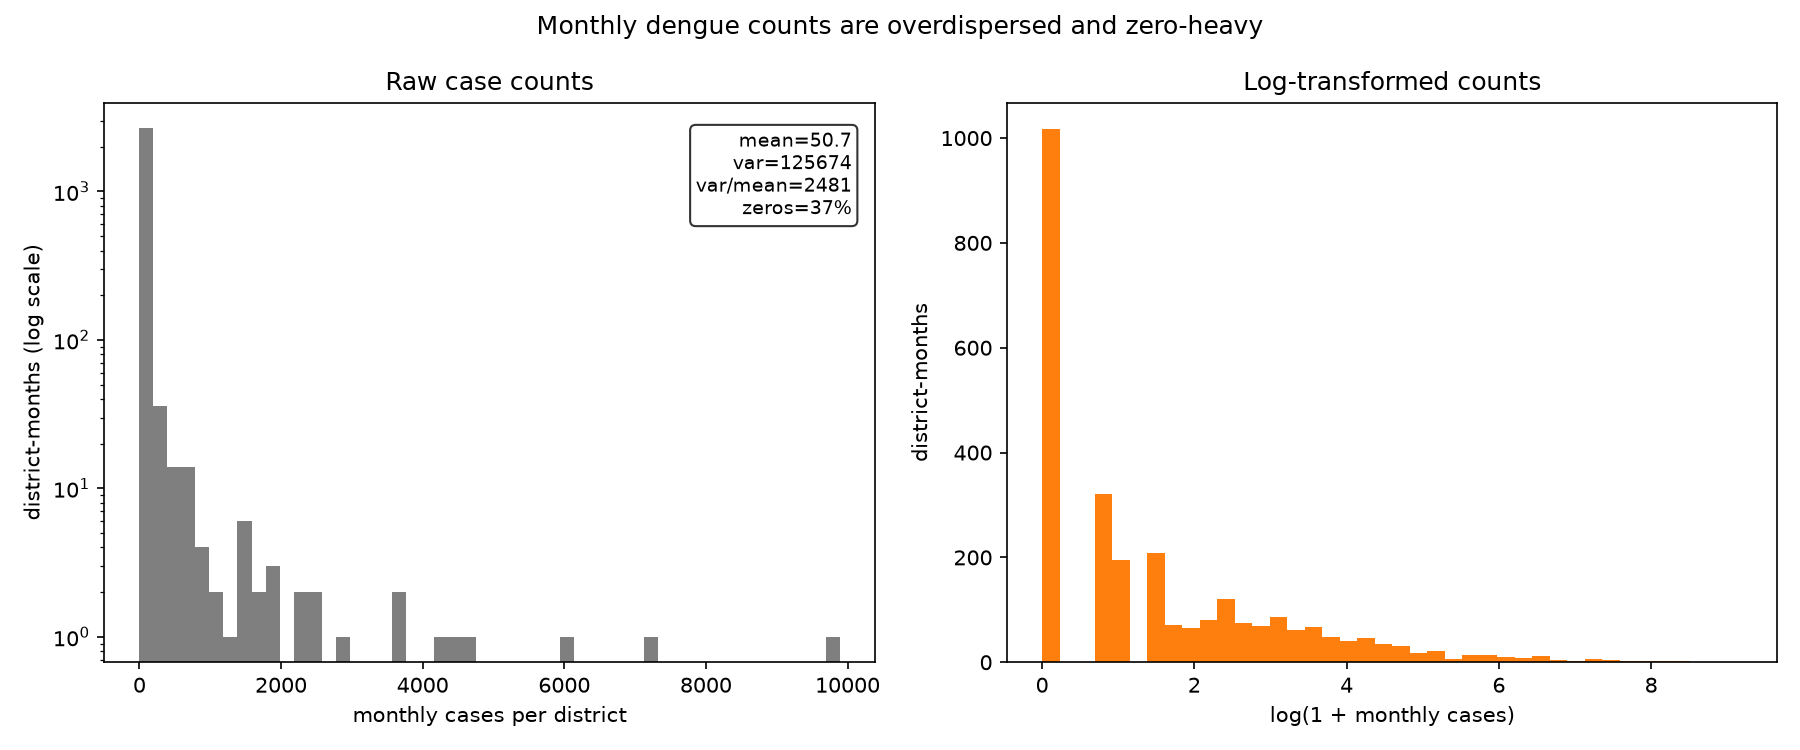

In [7]:
disp = eda.overdispersion(panel)
display(disp)
show(plots.plot_cases_distribution(panel, fig_dir / "cases_distribution.png"))

## Findings

The written summary — regenerated from these same numbers — lives in
[`reports/eda_findings.md`](../reports/eda_findings.md). Headlines:

- Cases concentrate in the **Hill** belt, then Terai; the Mountain belt is small but non-zero.
- Peak shifts **later with elevation** (Sep in Terai/Hill -> Oct in Mountain).
- Same-month climate correlations are weak -> motivates the **lag analysis**.
- Counts are heavily **overdispersed and zero-inflated** -> **negative binomial**.
- Per-band correlations differ -> keep the **climate x elevation interaction**.